# Exemplo 5 - Problema da Mochila Inteira


# 1. Configuração do Ambiente

Nesta etapa, configuramos o ambiente do Google Colab para utilizar a linguagem de otimização **CMPL**.

Essa célula deve ser executada apenas:
- Ao abrir o notebook pela primeira vez
- Ou quando o ambiente for reiniciado/desconectado

O que será feito:
- Download do COLIOP/CMPL (disponível em [coliop.org](https://www.coliop.org/download.html))
- Extração dos arquivos
- Configuração de variáveis de ambiente
- Inclusão das bibliotecas no Python

In [1]:
### Esta célula dever ser executada apenas quando o notebook for aberto
### ou quando o ambiente for desconectado e for necessário reconectá-lo
### por inatividade!

# Importação de bibliotecas do sistema
import os, sys

# Baixa o pacote do CMPL a partir do site oficial
os.system("wget https://www.coliop.org/_download/Cmpl-2-1-0-linux64.tar.gz")

# Extrai o arquivo baixado
os.system("tar -xzf Cmpl-2-1-0-linux64.tar.gz")

# Define o diretório principal do CMPL
os.environ["CMPLHOME"] = "/content/Cmpl-2-1-0-linux64"

# Adiciona o executável do CMPL ao PATH do sistema
os.environ["PATH"] += ":/content/Cmpl-2-1-0-linux64/bin"

# Configura bibliotecas compartilhadas necessárias
os.environ["LD_LIBRARY_PATH"] = "/content/Cmpl-2-1-0-linux64/bin/lib:" + os.environ.get("LD_LIBRARY_PATH", "")

# Adiciona os módulos Python do CMPL ao caminho de importação
sys.path.append("/content/Cmpl-2-1-0-linux64/pyCmpl")
sys.path.append("/content/Cmpl-2-1-0-linux64/pyCmpl/lib3")
sys.path.append("/content/Cmpl-2-1-0-linux64/pyCmpl/scripts/Unix")

# 2. Definição do Modelo de Otimização

Aqui definimos um problema de **programação linear inteira** usando a linguagem do CMPL.

## 2.1 Objetivo:
Maximizar a quantidade de calorias da mochila

## 2.2 Elementos do modelo:
- **I**: Conjunto de alimentos disponíveis.
- **Kcal**: Valor calórico de cada alimento disponível.
- **Massa**: Massa em kilogramas de cada alimento disponível.
- **K**: Capacidade máxima em kilogramas da mochila.

## 2.3 Variável de decisão:
- `x[i]`: quantidade de unidades do alimento `i` alocado na mochila.

In [2]:
# Definição do modelo combinado (dados e generalização) em linguagem CMPL (como string)
codigo_cmpl = """
par:
    # Conjunto de índices de 1 a 6
    I := set(1..6);

    # Coeficientes de utilidade/retorno na Função Objetivo
    KCAL[I] := (3500, 5200, 2800, 6500, 3900, 4500);

    # Coeficientes de peso/consumo de recursos de cada variável x_i
    MASSA[I] := (0.6, 0.7, 0.9, 1.5, 0.8, 1.0);

    # Limite máximo de capacidade do recurso
    K := 4.5;

var:
    # Vetor de variáveis inteiras e não-negativas (x_i >= 0 e inteiras)
    x[I] : integer[0..];

obj:
    # Função Objetivo: Maximizar a quantidade de calorias da mochila
    z: sum{i in I: KCAL[i] * x[i]} -> max;

con:
    # Restrição: Garantir que o consumo total não ultrapasse o limite 'K'
    LimiteRecurso{: sum{i in I: MASSA[i] * x[i]} <= K;}

"""

# Salva o modelo em um arquivo .cmpl
with open("/content/Exemplo-5_problema_da_mochila.cmpl", "w") as f:
    f.write(codigo_cmpl)

# 3. Resolução do Modelo

Nesta etapa utilizamos a **API Python pyCmpl** para fazer a integração entre modelo e resolvedor:
1. Carregamos o modelo criado
2. Executamos o solver
3. Exibimos o relatório da solução
4. Tratamento de erro para capturar possíveis problemas.

Também é possível fazer a entrada de dados por um arquivo python, atribuindo valores para conjuntos e parâmetros do modelo, utilizando atributos e métodos do pyCmpl. Isto será objeto para outra aula.

In [4]:
# Importa a biblioteca do CMPL para Python
from pyCmpl import *

try:
    # Cria o objeto do modelo a partir do arquivo
    modelo = Cmpl("/content/Exemplo-5_problema_da_mochila.cmpl")

    # Resolve o problema de otimização
    modelo.solve()

    # Exibe o relatório da solução (valores ótimos)
    modelo.solutionReport()

except CmplException as e:
    # Caso ocorra erro, exibe a mensagem
    print(e.msg)

---------------------------------------------------------------------------------------------------------
Problem              Exemplo-5_problema_da_mochila.cmpl
Nr. of variables     6
Nr. of constraints   1
Objective name       z
Solver name          HIGHS
Display variables    (all)
Display constraints  (all)
---------------------------------------------------------------------------------------------------------

Objective status     INTEGER OPTIMAL
Objective value      31200.00            (max!)

Variables           
Name                 Type            Activity          LowerBound          UpperBound            Marginal
---------------------------------------------------------------------------------------------------------
x[1]                    I                   0                0.00                 inf                   -
x[2]                    I                   6                0.00                 inf                   -
x[3]                    I                   0     

In [ ]:
#@title Função para visualização de dados

import re
import numpy as np
import matplotlib.pyplot as plt


def extrair_producao(codigo_cmpl):
    """
    Extrai a matriz PRODUCAO diretamente
    do código CMPL utilizado no modelo.
    """

    padrao = r"PRODUCAO\[J,\s*I\]\s*:=\s*\((.*?)\);"

    resultado = re.search(
        padrao,
        codigo_cmpl,
        re.DOTALL
    )

    if resultado is None:
        raise ValueError(
            "PRODUCAO não encontrada no código CMPL."
        )

    bloco = resultado.group(1)

    # Remove comentários
    bloco = re.sub(
        r"#.*",
        "",
        bloco
    )

    # Extrai as linhas da matriz
    linhas = re.findall(
        r"\(([^()]*)\)",
        bloco
    )

    matriz = []

    for linha in linhas:

        valores = [
            float(valor.strip())
            for valor in linha.split(",")
            if valor.strip()
        ]

        matriz.append(valores)

    return np.array(matriz)

def extrair_perda(codigo_cmpl):
    """
    Extrai automaticamente o parâmetro PERDA[I]
    definido no código CMPL.
    """

    padrao = r"PERDA\[I\]\s*:=\s*\((.*?)\);"

    resultado = re.search(
        padrao,
        codigo_cmpl,
        re.DOTALL
    )

    if resultado is None:
        raise ValueError(
            "PERDA não encontrada no código CMPL."
        )

    valores = [
        float(valor.strip())
        for valor in resultado.group(1).split(",")
        if valor.strip()
    ]

    return np.array(valores)

def grafico_padroes_corte(modelo, codigo_cmpl):

    # ============================================================
    # 1. Recuperar PRODUCAO automaticamente do modelo CMPL
    # ============================================================

    PRODUCAO = extrair_producao(codigo_cmpl)

    # ============================================================
    # 2. Número de padrões
    # ============================================================

    numero_padroes = PRODUCAO.shape[1]

    padroes = np.arange(
        1,
        numero_padroes + 1
    )

    # ============================================================
    # 3. Quantidade de utilizações de cada padrão
    # ============================================================

    quantidades = np.array([
        modelo.x[i].activity
        for i in padroes
    ])

    # ============================================================
    # 4. Composição dos padrões
    # ============================================================

    composicao = PRODUCAO

    # ============================================================
    # 5. Total de peças em cada padrão
    # ============================================================

    total_pecas = composicao.sum(
        axis=0
    )

    # ============================================================
    # 6. Percentual de cada tipo de peça
    # ============================================================

    percentuais = np.divide(
        composicao,
        total_pecas,
        out=np.zeros_like(
            composicao,
            dtype=float
        ),
        where=total_pecas != 0
    )

    # ============================================================
    # 7. Altura dos segmentos
    # ============================================================

    alturas = (
        percentuais
        * quantidades
    )

    # ============================================================
    # 8. Criar figura
    # ============================================================

    fig, ax = plt.subplots(
        figsize=(14, 8)
    )

    # ============================================================
    # 9. Configuração visual
    # ============================================================

    cores = [
        "#1976D2",  # 1,5 m
        "#43A047",  # 2,5 m
        "#FB8C00"   # 3,5 m
    ]

    nomes = [
        "Tábua de 1,5 m",
        "Tábua de 2,5 m",
        "Tábua de 3,5 m"
    ]

    # ============================================================
    # 10. Barras empilhadas
    # ============================================================

    base = np.zeros(
        numero_padroes
    )

    for tipo in range(
        composicao.shape[0]
    ):

        valores = alturas[tipo]

        ax.bar(
            padroes,
            valores,
            bottom=base,
            color=cores[tipo],
            label=nomes[tipo]
        )

        # ========================================================
        # Percentuais dentro das barras
        # ========================================================

        for i in range(
            numero_padroes
        ):

            percentual = percentuais[
                tipo,
                i
            ]

            if percentual > 0 and quantidades[i] > 0:

                ax.text(
                    padroes[i],
                    base[i]
                    + valores[i] / 2,
                    f"{percentual * 100:.0f}%",
                    ha="center",
                    va="center",
                    color="white",
                    fontsize=11,
                    fontweight="bold"
                )

        base += valores

    # ============================================================
    # 11. Quantidade de utilizações
    # ============================================================

    for i, quantidade in enumerate(
        quantidades
    ):

        if quantidade > 0:

            ax.text(
                padroes[i],
                quantidade + 5,
                f"{int(quantidade)}",
                ha="center",
                va="bottom",
                fontsize=11,
                fontweight="bold"
            )

    # ============================================================
    # 12. Eixo Y — limite automático
    # ============================================================

    maior_valor = np.max(
        quantidades
    )

    # Adiciona 15% de espaço acima da maior barra
    limite_superior = maior_valor * 1.15

    ax.set_ylim(
        0,
        limite_superior
    )

    # O Matplotlib define automaticamente os intervalos
    # do eixo Y.

    ax.set_ylabel(
        "Quantidade de tábuas cortadas no padrão",
        fontsize=12
    )

    # ============================================================
    # 13. Eixo X
    # ============================================================

    ax.set_xticks(
        padroes
    )

    ax.set_xticklabels(
        [
            f"Padrão {i}"
            for i in padroes
        ],
        fontsize=11
    )

    ax.set_xlabel(
        "Padrão de corte",
        fontsize=12
    )

    # ============================================================
    # 14. Grade
    # ============================================================

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    ax.set_axisbelow(
        True
    )

    # ============================================================
    # 15. Título
    # ============================================================

    ax.set_title(
        "Solução ótima — utilização dos padrões de corte",
        fontsize=18,
        fontweight="bold",
        pad=20
    )

    # ============================================================
    # 16. Legenda
    # ============================================================

    ax.legend(
        loc="upper right",
        frameon=False
    )

    # ============================================================
    # 17. Estética
    # ============================================================

    ax.spines[
        "top"
    ].set_visible(False)

    ax.spines[
        "right"
    ].set_visible(False)

    plt.tight_layout()

    plt.show()



def grafico_tabuas_atendidas(modelo, codigo_cmpl):

    # ============================================================
    # 1. Obter os valores de AtenderDemanda
    # ============================================================

    indices = list(modelo.AtenderDemanda.keys())

    quantidades = np.array([
        modelo.AtenderDemanda[i].activity
        for i in indices
    ])

    # ============================================================
    # 2. Obter PERDA do modelo CMPL
    # ============================================================

    PERDA = extrair_perda(codigo_cmpl)

    # ============================================================
    # 3. Obter quantidade de utilizações de cada padrão
    # ============================================================

    numero_padroes = len(PERDA)

    padroes = np.arange(
        1,
        numero_padroes + 1
    )

    utilizacoes = np.array([
        modelo.x[i].activity
        for i in padroes
    ])

    # ============================================================
    # 4. Calcular perda total
    #
    # PERDA[i] = perda por utilização do padrão
    #
    # Perda total = PERDA[i] × x[i]
    # ============================================================

    perda_total = np.sum(
        PERDA * utilizacoes
    )

    # ============================================================
    # 5. Nomes dos tipos
    # ============================================================

    nomes = {
        1: "1,5 m",
        2: "2,5 m",
        3: "3,5 m"
    }

    tipos = [
        nomes[i]
        for i in indices
    ]

    # ============================================================
    # 6. Adicionar a perda
    # ============================================================

    tipos.append(
        "Perda"
    )

    quantidades_grafico = np.append(
        quantidades,
        perda_total
    )

    # ============================================================
    # 7. Cores
    # ============================================================

    cores = {
        1: "#1976D2",
        2: "#43A047",
        3: "#FB8C00"
    }

    cores_barras = [
        cores[i]
        for i in indices
    ]

    cores_barras.append(
        "#BDBDBD"
    )

    # ============================================================
    # 8. Criar gráfico
    # ============================================================

    fig, ax = plt.subplots(
        figsize=(11, 7)
    )

    barras = ax.bar(
        tipos,
        quantidades_grafico,
        color=cores_barras,
        width=0.6
    )

    # ============================================================
    # 9. Valores sobre as barras
    # ============================================================

    for i, (barra, quantidade) in enumerate(
        zip(
            barras,
            quantidades_grafico
        )
    ):

        if quantidade > 0:

            # Para as tábuas → unidades
            if i < len(indices):

                texto = (
                    f"{int(round(quantidade))}"
                )

            # Para a perda → metros
            else:

                texto = (
                    f"{quantidade:.1f} m"
                )

            ax.text(
                barra.get_x()
                + barra.get_width() / 2,
                barra.get_height()
                + max(quantidades_grafico) * 0.015,
                texto,
                ha="center",
                va="bottom",
                fontsize=14,
                fontweight="bold"
            )

    # ============================================================
    # 10. Eixos
    # ============================================================

    ax.set_xlabel(
        "Tipo de produção",
        fontsize=12
    )

    ax.set_ylabel(
        "Quantidade",
        fontsize=12
    )

    # ============================================================
    # 11. Título
    # ============================================================

    ax.set_title(
        "Quantidade de tábuas produzidas e perda",
        fontsize=17,
        fontweight="bold",
        pad=20
    )

    # ============================================================
    # 12. Grade
    # ============================================================

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    ax.set_axisbelow(
        True
    )

    # ============================================================
    # 13. Aparência
    # ============================================================

    ax.spines[
        "top"
    ].set_visible(False)

    ax.spines[
        "right"
    ].set_visible(False)

    plt.tight_layout()

    plt.show()

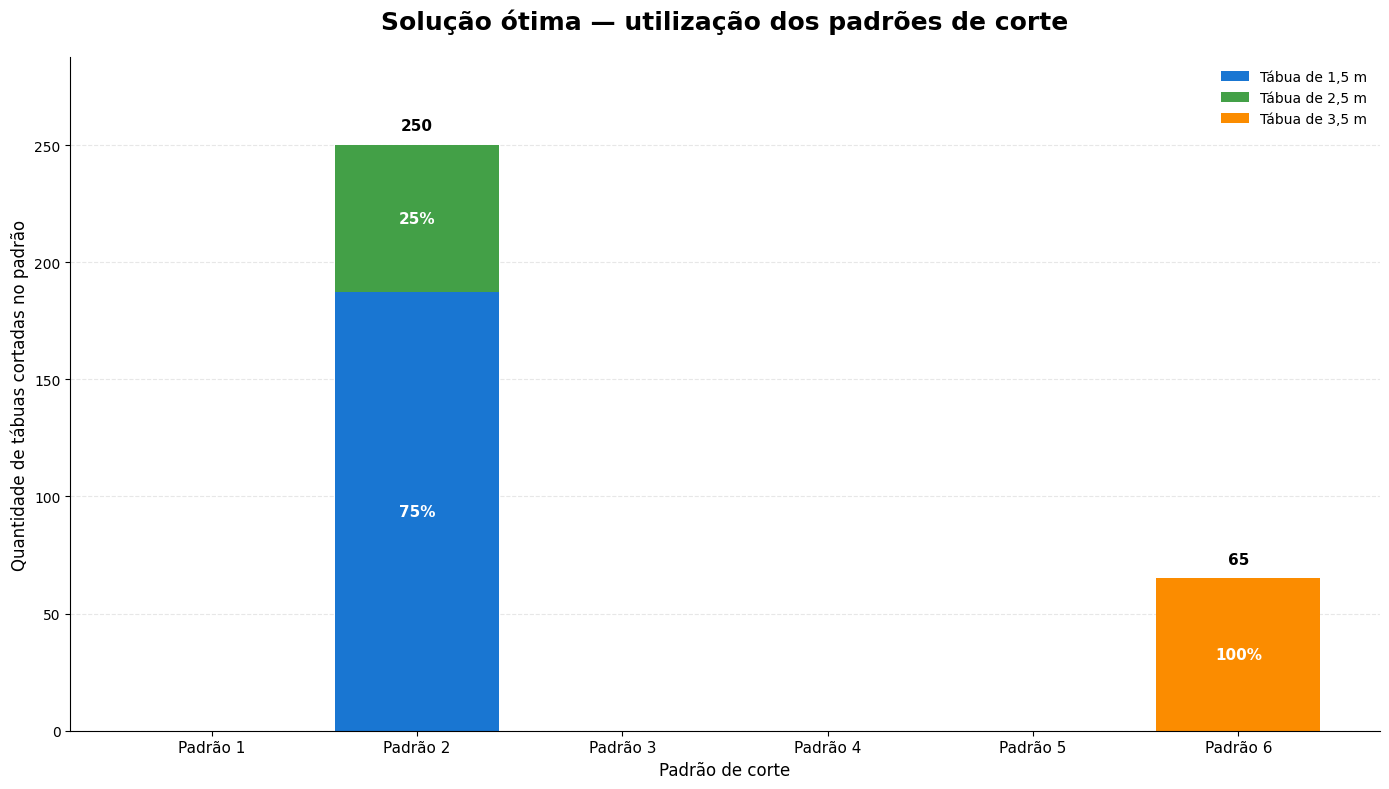

In [ ]:
grafico_padroes_corte(
    modelo,
    codigo_cmpl
)

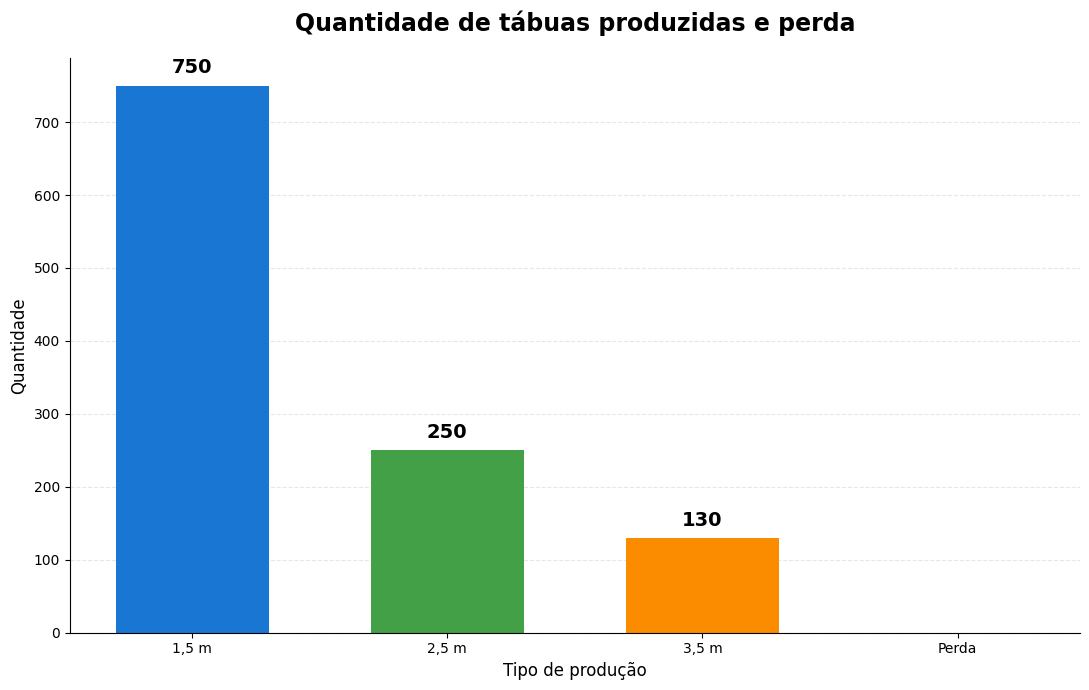

In [ ]:
grafico_tabuas_atendidas(modelo,codigo_cmpl)

# Source code

The source code is available on Github:
Cmpl official realeases: https://github.com/coin-or/Cmpl

Cmpl working git: https://github.com/MikeSteglich/Cmpl2

Coliop: https://github.com/MikeSteglich/Coliop

pyCmpl: https://github.com/MikeSteglich/pyCmpl3